# DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

## Table of Contents

### 1. What is DBSCAN?

### 2. DBSCAN in Scikit-Learn

### 3. Evaluation of Clustering

### 4. Important Considerations for DBSCAN




### 1. What is DBSCAN?

DBSCAN is a density-based clustering algorithm that groups together points that are closely packed together, while labeling points in low-density regions as outliers

## How DBSCAN Works:

### Step 1: Define Density
- For each point, find its **neighbors within a distance `eps`**.  
- Count how many neighbors are inside this radius.  

A point is considered a **core point** if it has at least `min_samples` neighbors


### Step 2: Identify Core, Border and Noise Points

1. **Core point** â†’ dense region  
2. **Border point** â†’ not dense itself, but within `eps` of a core point  
3. **Noise point** â†’ neither core nor border (isolated points)
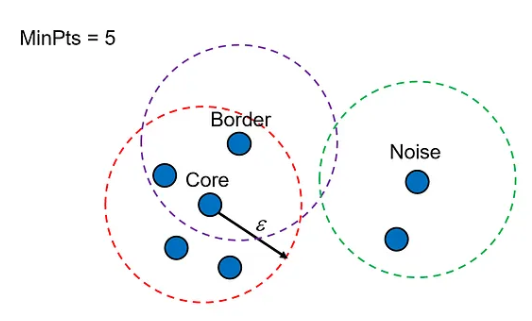

### Step 3: Form Clusters
- Start with an unvisited point:
  1. If it is a **core point**, create a new cluster  
  2. Expand the cluster by adding **all neighbors** within `eps`
- Recursively check neighbors:
  - If neighbor is a core point, add its neighbors too  
  - If neighbor is a border point, add it to the cluster

- Continue until all reachable points from this core point are assigned.


### Step 4: Handle Remaining Points
- Any point that is not assigned to a cluster is labeled as **noise (-1)**.


### Step 5: Output
- Each cluster gets a unique label  
- Noise points are labeled `-1`  

###Result: clusters + noise points

## 2. DBSCAN in Scikit-Learn

### **Most Important Parameters**

#### **1. `epslon`**

Maximum distance between two points for them to be considered neighbors. Controls how close points must be to form clusters

- Smaller `eps` â†’ more points are labeled as **noise**  

- Larger `eps` â†’ clusters may merge, fewer noise points  


#### **2. `min_samples`**

Minimum number of points required to form a **dense region (core point)**. Determines how strict the algorithm is about forming clusters.

**Default:** 5  

- Smaller â†’ clusters form more easily, fewer noise points

- Larger â†’ only dense regions form clusters, more noise points  

**Notes:**  

Often set to **double number of dimension** for small datasets, or higher for noisy data

#### **3. `metric`**
  
Distance metric used to calculate proximity between points. Determines which points are considered â€œneighborsâ€?

**Default:** `euclidean`

**Common options:**  
  - `euclidean` â†’ straight-line distance; most common for numeric features  
  - `manhattan` â†’ sum of absolute differences; robust to outliers  
  - `cosine` â†’ measures angle between vectors; useful for text embeddings  

**Rule of thumb:**  
Choice of metric affects cluster shape and which points are considered close.  

## Apply DBSCAN to a simple Dataset

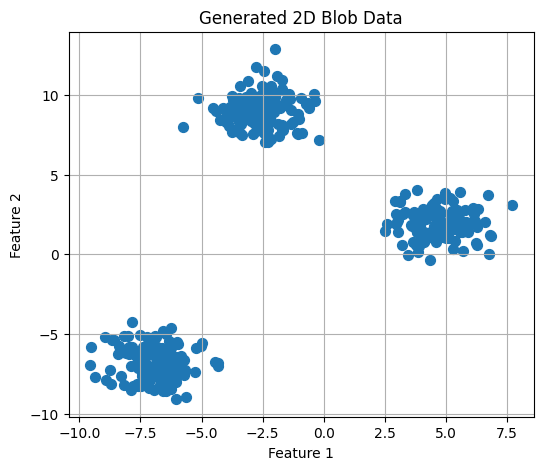

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import seaborn as sns
from sklearn.cluster import DBSCAN


# Generate 2D data: 400 points, 3 centers
X, y = make_blobs(n_samples=400, n_features=2, centers=3, random_state=42)

# Plot the dataset
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Generated 2D Blob Data")
plt.grid(True)
plt.show()

In [ ]:

# Create DBSCAN model
dbscan = DBSCAN(
    eps=1.2,        # neighborhood radius
    min_samples=5,  # minimum points to form a cluster
    metric='euclidean'
)

# Fit and predict cluster labels
labels = dbscan.fit_predict(X)

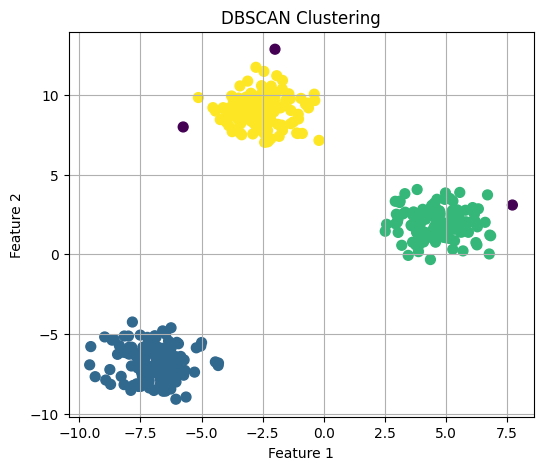

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("DBSCAN Clustering")
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import silhouette_score

# Compute silhouette score, ignoring noise points
mask = labels != -1
score = silhouette_score(X[mask], labels[mask])
print("Silhouette Score (excluding noise points):", score)

Silhouette Score (excluding noise points): 0.8480963132111413


In [ ]:
outlier_percent = []

for eps in np.linspace(0.001,3,50):

    # Create Model
    dbscan = DBSCAN(eps=eps)
    cluster_labels = dbscan.fit_predict(X)


    # Log percentage of points that are outliers
    perc_outliers = 100 * np.sum(dbscan.labels_ == -1) / len(cluster_labels)

    outlier_percent.append(perc_outliers)

Text(0.5, 0, 'Epsilon Value')

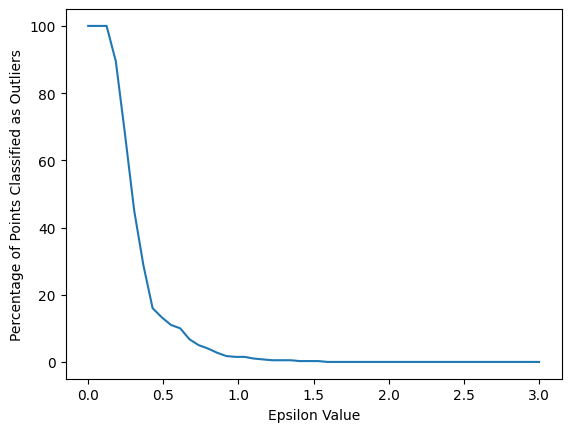

In [ ]:
sns.lineplot(x=np.linspace(0.001,3,50),y=outlier_percent)
plt.ylabel("Percentage of Points Classified as Outliers")
plt.xlabel("Epsilon Value")

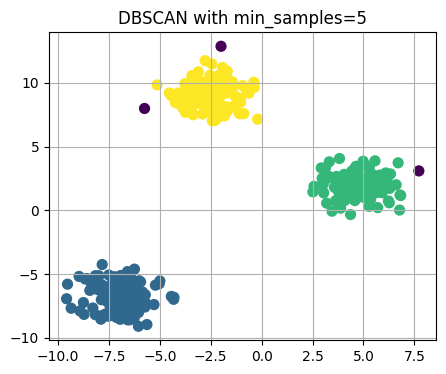

min_samples=5 â†’ Silhouette Score: 0.848


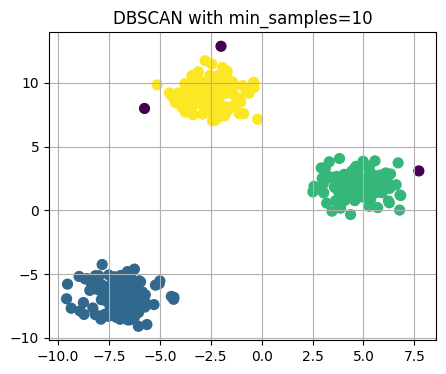

min_samples=10 â†’ Silhouette Score: 0.848


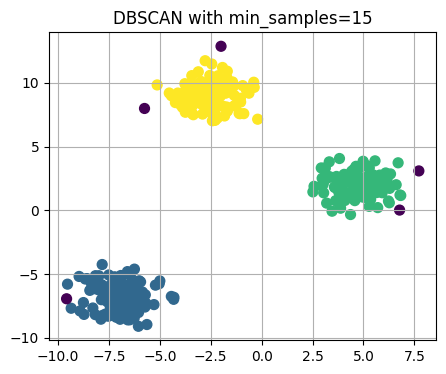

min_samples=15 â†’ Silhouette Score: 0.849


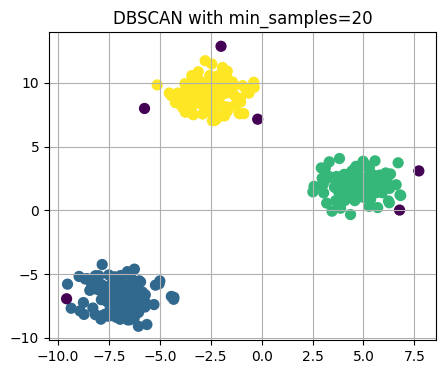

min_samples=20 â†’ Silhouette Score: 0.850


In [ ]:
#Varying min_samples
min_samples_values = [5, 10, 15, 20]

for min_samples in min_samples_values:
    # Apply DBSCAN
    dbscan = DBSCAN(eps=1.2, min_samples=min_samples)
    labels = dbscan.fit_predict(X)

    # Visualize clusters
    plt.figure(figsize=(5,4))
    plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=50)
    plt.title(f"DBSCAN with min_samples={min_samples}")
    plt.grid(True)
    plt.show()

    # Compute silhouette score (ignore noise)
    mask = labels != -1  # exclude noise
    if len(set(labels[mask])) > 1:  # silhouette score requires >=2 clusters
        score = silhouette_score(X[mask], labels[mask])
        print(f"min_samples={min_samples} â†’ Silhouette Score: {score:.3f}")
    else:
        print(f"min_samples={min_samples} â†’ Too few clusters to compute silhouette score")

## Task 2B: DBSCAN

Dataset: `CC GENERAL.csv`  
Goal: Use **DBSCAN** to find clusters of customers and identify potential outliers.


## 1. Exploratory Data Analysis (EDA)



In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [19]:
df = pd.read_csv('CC GENERAL.csv')
print(f'Shape: {df.shape[0]:,} × {df.shape[1]}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: 8,950 × 18
Columns: ['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [20]:
print('Dataset Info:')
df.info()
print('\nStatistics:')
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [21]:
print('Missing Values:')
missing = df.isnull().sum()
if missing.sum() == 0:
    print('âœ“ None')
else:
    print(missing[missing > 0])

Missing Values:
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64


In [22]:
print('Removing Outliers (IQR Method)')
print('='*60)
numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != 'CUST_ID']
outliers_mask = pd.Series([False] * len(df))

for col in numeric_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1-1.5*IQR) | (df[col] > Q3+1.5*IQR))
    if outliers.sum() > 0:
        print(f'{col:30s}: {outliers.sum():4d} outliers')
        outliers_mask |= outliers

original = len(df)
df = df[~outliers_mask].copy()
print(f'\n Removed {original-len(df):,} rows')
print(f'  Clean data: {len(df):,} rows')

Removing Outliers (IQR Method)
BALANCE                       :  695 outliers
BALANCE_FREQUENCY             : 1493 outliers
PURCHASES                     :  808 outliers
ONEOFF_PURCHASES              : 1013 outliers
INSTALLMENTS_PURCHASES        :  867 outliers
CASH_ADVANCE                  : 1030 outliers
ONEOFF_PURCHASES_FREQUENCY    :  782 outliers
CASH_ADVANCE_FREQUENCY        :  525 outliers
CASH_ADVANCE_TRX              :  804 outliers
PURCHASES_TRX                 :  766 outliers
CREDIT_LIMIT                  :  248 outliers
PAYMENTS                      :  808 outliers
MINIMUM_PAYMENTS              :  841 outliers
PRC_FULL_PAYMENT              : 1474 outliers
TENURE                        : 1366 outliers

 Removed 5,956 rows
  Clean data: 2,994 rows


## 2. Data Preparation

In [23]:
df_cluster = df.drop('CUST_ID', axis=1)
print(f'CUST_ID dropped')

if df_cluster.isnull().sum().sum() > 0:
    df_cluster = df_cluster.fillna(df_cluster.median())
    print('Missing filled')
else:
    print('No missing values')

print(f'Shape: {df_cluster.shape}')

CUST_ID dropped
Missing filled
Shape: (2994, 17)


In [24]:
# SCALE (CRITICAL!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)
print('✓ FEATURES SCALED')
print(f'  All features: mean≈0, std≈1')
print(f'  Shape: {X_scaled.shape}')

✓ FEATURES SCALED
  All features: mean≈0, std≈1
  Shape: (2994, 17)


## 3. Apply DBSCAN




In [25]:
eps = 0.5
min_samples = 10

print(f'DBSCAN Parameters:')
print(f'  eps={eps}, min_samples={min_samples}')

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f'\nResults:')
print(f'  Clusters: {n_clusters}')
print(f'  Outliers: {n_noise} ({n_noise/len(labels)*100:.1f}%)')
print('\nDistribution:')
for i in range(-1, n_clusters):
    count = (labels == i).sum()
    pct = count/len(labels)*100
    label = 'NOISE' if i == -1 else f'Cluster {i}'
    print(f'  {label:12s}: {count:5,} ({pct:5.1f}%)')

DBSCAN Parameters:
  eps=0.5, min_samples=10

Results:
  Clusters: 6
  Outliers: 2784 (93.0%)

Distribution:
  NOISE       : 2,784 ( 93.0%)
  Cluster 0   :    18 (  0.6%)
  Cluster 1   :   106 (  3.5%)
  Cluster 2   :    48 (  1.6%)
  Cluster 3   :    10 (  0.3%)
  Cluster 4   :    18 (  0.6%)
  Cluster 5   :    10 (  0.3%)


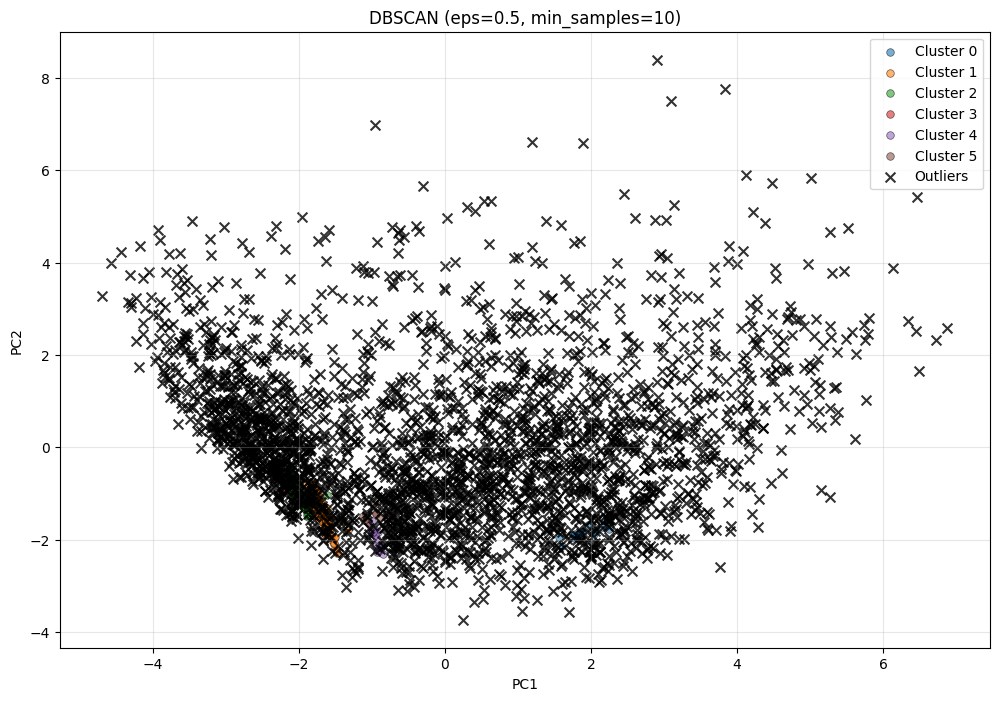

Variance explained: 48.5%


In [26]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))

if n_clusters > 0:
    for i in range(n_clusters):
        mask = labels == i
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                   label=f'Cluster {i}', s=30, alpha=0.6, edgecolors='k', linewidth=0.5)

if n_noise > 0:
    noise_mask = labels == -1
    plt.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1], 
               c='black', marker='x', s=50, alpha=0.8, label='Outliers')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'DBSCAN (eps={eps}, min_samples={min_samples})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f'Variance explained: {sum(pca.explained_variance_ratio_)*100:.1f}%')

## 4. Evaluate the Clustering

In [33]:
print('='*60)
print('EVALUATION')
print('='*60)

if n_clusters > 1:
    mask = labels != -1
    if mask.sum() > 0:
        score = silhouette_score(X_scaled[mask], labels[mask])
        print(f'Silhouette (no noise): {score:.4f}')
        
        if score > 0.7:
            print('STRONG')
        elif score > 0.5:
            print('MODERATE')
        elif score > 0.25:
            print('WEAK')
        else:
            print('POOR')
else:
    print('Need >1 cluster for Silhouette')

print(f'\nOutliers: {n_noise} ({n_noise/len(labels)*100:.1f}%)')
if n_noise/len(labels)*100 < 5:
    print('Good outlier ratio')
else:
    print('Many outliers - try different params')
print('='*60)

EVALUATION
Silhouette (no noise): 0.3361
WEAK

Outliers: 2784 (93.0%)
Many outliers - try different params


In [28]:
if n_clusters > 0:
    df_analysis = df_cluster.copy()
    df_analysis['Cluster'] = labels
    df_clustered = df_analysis[df_analysis['Cluster'] != -1]
    
    if len(df_clustered) > 0:
        print('Cluster Means:')
        print('='*80)
        means = df_clustered.groupby('Cluster').mean()
        print(means.round(2))
        
        print('\nTop 3 Features per Cluster:')
        for i in range(n_clusters):
            if i in means.index:
                print(f'\nCluster {i} ({(labels==i).sum()} customers):')
                top3 = means.loc[i].nlargest(3)
                for feat, val in top3.items():
                    print(f'  {feat:30s}: {val:>8.2f}')

Cluster Means:
         BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
Cluster                                                            
0         108.31                1.0     262.35              0.00   
1        1165.49                1.0       0.17              0.00   
2        1277.35                1.0       1.30              0.00   
3        1367.14                1.0       0.00              0.00   
4         728.49                1.0      45.91             45.56   
5        1182.36                1.0      99.30             99.30   

         INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
Cluster                                                              
0                        262.35          0.00                 0.99   
1                          0.36        127.81                 0.00   
2                          1.30        150.99                 0.00   
3                          0.00        116.29                 0.00   
4                   

In [29]:
if n_noise > 0:
    print('OUTLIER ANALYSIS')
    print('='*60)
    
    df_temp = df_cluster.copy()
    df_temp['Cluster'] = labels
    
    outliers = df_temp[df_temp['Cluster'] == -1].drop('Cluster', axis=1)
    clustered = df_temp[df_temp['Cluster'] != -1].drop('Cluster', axis=1)
    
    if len(clustered) > 0 and len(outliers) > 0:
        print('\nOutliers vs Clustered (Average Values):')
        comp = pd.DataFrame({
            'Outliers': outliers.mean(),
            'Clustered': clustered.mean(),
            'Difference': outliers.mean() - clustered.mean()
        })
        print(comp.round(2))
        
        print('\nBiggest Differences:')
        top5 = comp['Difference'].abs().nlargest(5)
        for feat in top5.index:
            diff = comp.loc[feat, 'Difference']
            print(f'{feat:30s}: {diff:+8.2f}')

OUTLIER ANALYSIS

Outliers vs Clustered (Average Values):
                                  Outliers  Clustered  Difference
BALANCE                            1213.55    1073.39      140.16
BALANCE_FREQUENCY                     0.98       1.00       -0.02
PURCHASES                           401.92      31.53      370.38
ONEOFF_PURCHASES                    213.91       8.63      205.27
INSTALLMENTS_PURCHASES              188.27      22.99      165.28
CASH_ADVANCE                        440.70     104.56      336.13
PURCHASES_FREQUENCY                   0.41       0.10        0.32
ONEOFF_PURCHASES_FREQUENCY            0.12       0.01        0.11
PURCHASES_INSTALLMENTS_FREQUENCY      0.32       0.09        0.23
CASH_ADVANCE_FREQUENCY                0.10       0.09        0.01
CASH_ADVANCE_TRX                      1.82       1.20        0.62
PURCHASES_TRX                         8.12       1.19        6.94
CREDIT_LIMIT                       3325.03    1428.81     1896.22
PAYMENTS          

## 5. Tune DBSCAN Parameters

Since 93% of points were labeled as noise, the parameters need tuning.
DBSCAN handles outliers on its own, so we reload data without IQR removal and tune eps and min_samples.

Full dataset shape: (8950, 17)


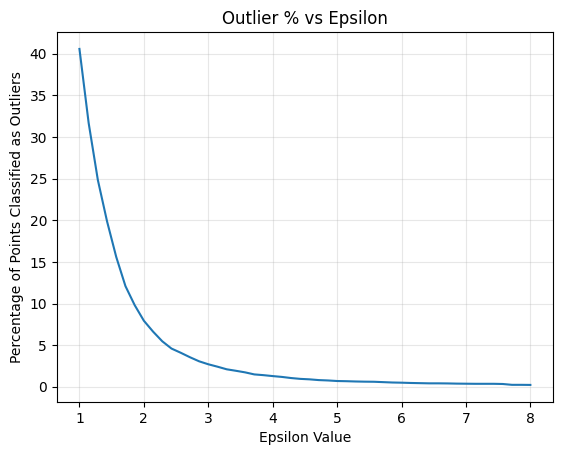

In [30]:
# Reload data WITHOUT outlier removal (DBSCAN handles outliers itself)
df_raw = pd.read_csv('CC GENERAL.csv')
df_raw = df_raw.drop('CUST_ID', axis=1)
df_raw = df_raw.fillna(df_raw.median())

scaler2 = StandardScaler()
X_scaled2 = scaler2.fit_transform(df_raw)
print(f'Full dataset shape: {X_scaled2.shape}')

# Tune eps using outlier percentage (same method as cell 8-9 in tutorial)
outlier_percent = []
eps_range = np.linspace(1, 8, 50)

for e in eps_range:
    db = DBSCAN(eps=e, min_samples=10)
    lbl = db.fit_predict(X_scaled2)
    perc = 100 * np.sum(lbl == -1) / len(lbl)
    outlier_percent.append(perc)

sns.lineplot(x=eps_range, y=outlier_percent)
plt.ylabel('Percentage of Points Classified as Outliers')
plt.xlabel('Epsilon Value')
plt.title('Outlier % vs Epsilon')
plt.grid(True, alpha=0.3)
plt.show()

In [31]:
# Try different eps and min_samples combinations
best_score = -1
best_params = {}

for e in [3, 4, 5, 6]:
    for ms in [5, 10, 15, 20]:
        db = DBSCAN(eps=e, min_samples=ms)
        lbl = db.fit_predict(X_scaled2)
        
        n_clust = len(set(lbl)) - (1 if -1 in lbl else 0)
        n_noise_pts = list(lbl).count(-1)
        noise_pct = n_noise_pts / len(lbl) * 100
        
        if n_clust > 1:
            mask = lbl != -1
            sc = silhouette_score(X_scaled2[mask], lbl[mask])
        else:
            sc = -1
        
        print(f'eps={e}, min_samples={ms:2d} -> clusters={n_clust}, noise={noise_pct:5.1f}%, silhouette={sc:.4f}')
        
        if sc > best_score and noise_pct < 50:
            best_score = sc
            best_params = {'eps': e, 'min_samples': ms}

print(f'Best params: {best_params}')
print(f'Best silhouette: {best_score:.4f}')

eps=3, min_samples= 5 -> clusters=1, noise=  2.4%, silhouette=-1.0000
eps=3, min_samples=10 -> clusters=1, noise=  2.7%, silhouette=-1.0000
eps=3, min_samples=15 -> clusters=1, noise=  3.0%, silhouette=-1.0000
eps=3, min_samples=20 -> clusters=1, noise=  3.1%, silhouette=-1.0000
eps=4, min_samples= 5 -> clusters=1, noise=  1.2%, silhouette=-1.0000
eps=4, min_samples=10 -> clusters=1, noise=  1.3%, silhouette=-1.0000
eps=4, min_samples=15 -> clusters=1, noise=  1.4%, silhouette=-1.0000
eps=4, min_samples=20 -> clusters=1, noise=  1.5%, silhouette=-1.0000
eps=5, min_samples= 5 -> clusters=2, noise=  0.6%, silhouette=0.7182
eps=5, min_samples=10 -> clusters=1, noise=  0.7%, silhouette=-1.0000
eps=5, min_samples=15 -> clusters=1, noise=  0.7%, silhouette=-1.0000
eps=5, min_samples=20 -> clusters=1, noise=  0.8%, silhouette=-1.0000
eps=6, min_samples= 5 -> clusters=2, noise=  0.3%, silhouette=0.7590
eps=6, min_samples=10 -> clusters=1, noise=  0.5%, silhouette=-1.0000
eps=6, min_samples=15 

BEST DBSCAN RESULTS
Parameters: eps=6, min_samples=5
Clusters found: 2
Noise points: 29 (0.3%)

  Cluster 0: 8,913 customers ( 99.6%)
  Cluster 1:     8 customers (  0.1%)
  NOISE    :    29 customers (  0.3%)
Silhouette Score (excluding noise): 0.7590


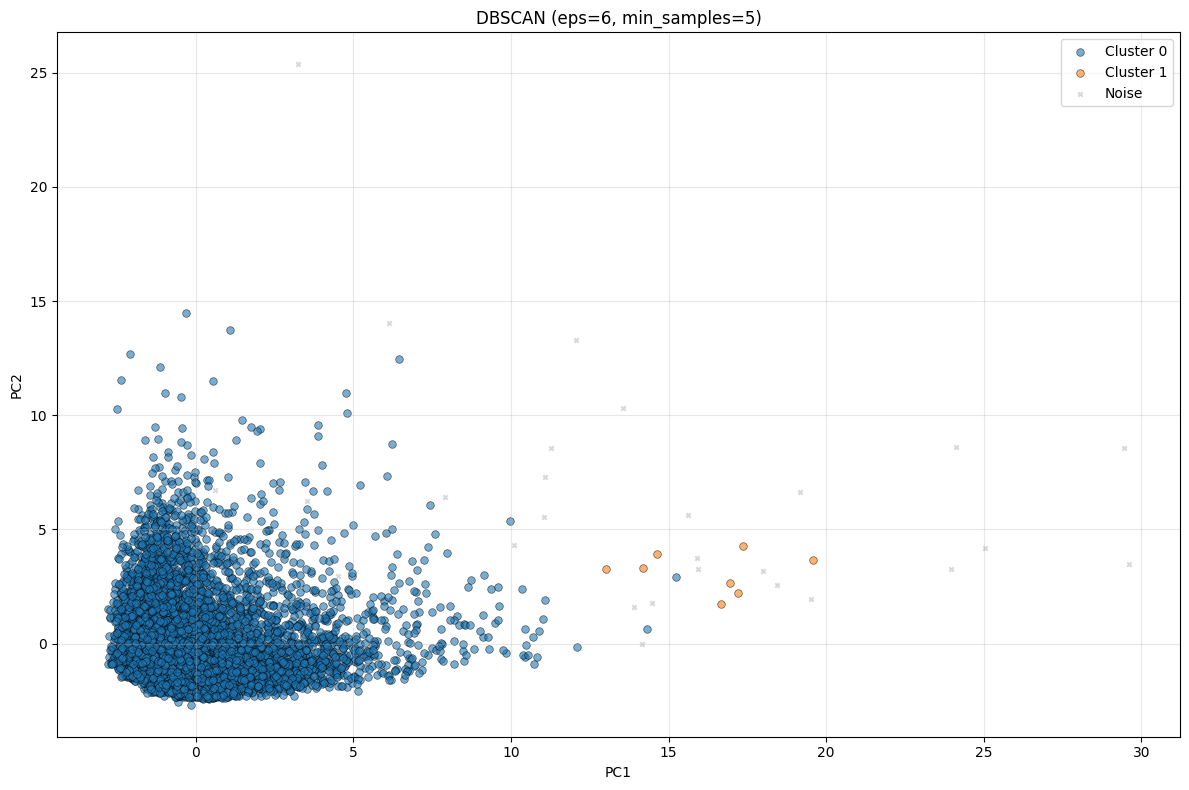

Variance explained by 2 PCA components: 47.6%


In [32]:
# Apply DBSCAN with best parameters
dbscan_best = DBSCAN(eps=best_params['eps'], min_samples=best_params['min_samples'])
labels_best = dbscan_best.fit_predict(X_scaled2)

n_clusters_best = len(set(labels_best)) - (1 if -1 in labels_best else 0)
n_noise_best = list(labels_best).count(-1)

print('BEST DBSCAN RESULTS')
print('='*60)
print(f'Parameters: eps={best_params["eps"]}, min_samples={best_params["min_samples"]}')
print(f'Clusters found: {n_clusters_best}')
print(f'Noise points: {n_noise_best} ({n_noise_best/len(labels_best)*100:.1f}%)')
print()

# Cluster distribution
for i in range(n_clusters_best):
    count = (labels_best == i).sum()
    pct = count / len(labels_best) * 100
    print(f'  Cluster {i}: {count:5,} customers ({pct:5.1f}%)')
print(f'  NOISE    : {n_noise_best:5,} customers ({n_noise_best/len(labels_best)*100:5.1f}%)')

# Silhouette score
mask_best = labels_best != -1
score_best = silhouette_score(X_scaled2[mask_best], labels_best[mask_best])
print(f'Silhouette Score (excluding noise): {score_best:.4f}')

# PCA visualization
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled2)

plt.figure(figsize=(12, 8))
for i in range(n_clusters_best):
    mask = labels_best == i
    plt.scatter(X_pca2[mask, 0], X_pca2[mask, 1], label=f'Cluster {i}', s=30, alpha=0.6, edgecolors='k', linewidth=0.5)

noise_mask = labels_best == -1
plt.scatter(X_pca2[noise_mask, 0], X_pca2[noise_mask, 1], c='gray', marker='x', s=10, alpha=0.3, label='Noise')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'DBSCAN (eps={best_params["eps"]}, min_samples={best_params["min_samples"]})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Variance explained by 2 PCA components: {sum(pca2.explained_variance_ratio_)*100:.1f}%')